### Implementing GPT-style Large Language Model (LLM) from scratch

Text processing workflow with neural networks
1. Tokenization (convert text to tokens and assings unique ID to each token)
2. Embedding (turn each token into a n-dimensional vector e.g.: 768 embedding dimension)
3. Positional encoding (add information about the token position in the sequence to the embedding vector)

### Download the training dataset

In [1]:
import requests

url = "https://raw.githubusercontent.com/ilya-pimenov/LLM-Study/refs/heads/main/the-verdict.txt"

response = requests.get(url)

raw_text = response.text
print(raw_text[:500])     # print first 500 characters

I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no great surprise to me to hear that, in the height of his glory, he had dropped his painting, married a rich widow, and established himself in a villa on the Riviera. (Though I rather thought it would have been Rome or Florence.)

"The height of his glory"--that was what the women called it. I can hear Mrs. Gideon Thwing--his last Chicago sitter--deploring his unaccountable abdication. "Of course it'


### Text tokenization

GPT-2 used the Byte-Pair Encoding (BPE) tokenization. We will use the BPE implementation from the tiktoken library.

In [2]:
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")

encoded_text = tokenizer.encode(raw_text)

print(f"Original text sample: {raw_text[:150]}")
print(f"Encoded text (first 20 tokens): {encoded_text[:20]}")
print(f"Total number of encoded tokens: {len(encoded_text)}")

Original text sample: I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no great surprise to me to hear that, in the height of
Encoded text (first 20 tokens): [40, 367, 2885, 1464, 1807, 3619, 402, 271, 10899, 2138, 257, 7026, 15632, 438, 2016, 257, 922, 5891, 1576, 438]
Total number of encoded tokens: 5146


### Custom dataset implementation

Custom dataset class implementation that will:

1. Tokenize the whole input text using BPE
2. Generate samples and labels for the next word prediction task

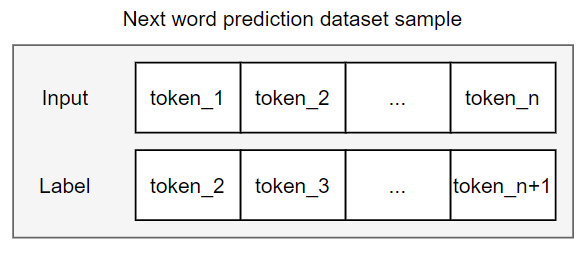

In [3]:
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn


class NextWordPredictionDataset(Dataset):
    def __init__(self, txt, tokenizer, max_length=256, stride=128):
        self.input_ids = []
        self.target_ids = []

        token_ids = tokenizer.encode(txt)

        for i in range(0, len(token_ids) - max_length, stride):
            input_chunk = token_ids[i:i + max_length]
            target_chunk = token_ids[i + 1: i + max_length + 1]
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]


dataset = NextWordPredictionDataset(raw_text, tokenizer)

In [4]:
input_1, label_1 = dataset[0]

# Input sample and label example (first 20 tokens)
print(f"Input training sample:\n {input_1[:20]}")
print(f"Label (shifted by 1 token compared to the input sample):\n {label_1[:20]}")

Input training sample:
 tensor([   40,   367,  2885,  1464,  1807,  3619,   402,   271, 10899,  2138,
          257,  7026, 15632,   438,  2016,   257,   922,  5891,  1576,   438])
Label (shifted by 1 token compared to the input sample):
 tensor([  367,  2885,  1464,  1807,  3619,   402,   271, 10899,  2138,   257,
         7026, 15632,   438,  2016,   257,   922,  5891,  1576,   438,   568])


### Token embeddings and positional encoding

Embedding means conversion of each token to n-dimensional vector. In the GPT-2-style models, it is implemented by the Embedding layer, which is at the input of the model. This layer is trainable, the model therefore learns the embeddings during training.


The LLM has no way to figure out the position of tokens in a sequence on its own. This would be a significant drawback for the model. We must therefore add the positional information to the token embeddings by using another Embedding layer.

In [5]:
vocabulary_size = 50257     # Size of the whole dictionary that the gpt-2 original tokenizer (implemented by the tiktoken library) operates with
embedding_dimension = 768   # Dimension of the vector that embedds one token
context_length = 256        # Number of tokens in one training sample

token_embedding_layer = nn.Embedding(vocabulary_size, embedding_dimension)
positional_encoding_layer = nn.Embedding(context_length, embedding_dimension)

token_embedding = token_embedding_layer(input_1)
positional_encoding = positional_encoding_layer(torch.arange(context_length))

output = token_embedding + positional_encoding # Positional information is added to the token embeddings by a simple addition operation

print(output[:20])
print(output.shape) # Each token is now represented by a vector of 768 elements


tensor([[-0.4846,  1.5414, -2.7453,  ..., -1.8231, -0.3139, -0.0166],
        [-0.9249,  1.9489,  1.2414,  ...,  1.5138, -2.2894, -0.5334],
        [-0.0592,  1.0913, -0.8465,  ..., -4.6846,  0.4121, -0.5780],
        ...,
        [ 1.1546,  0.3959, -0.3701,  ..., -0.1363, -0.1653, -0.4509],
        [-0.5866,  0.6884,  0.1821,  ...,  1.7553,  0.2934, -0.8575],
        [-1.8932, -0.8127, -1.3223,  ..., -1.6694, -0.7843, -0.3558]],
       grad_fn=<SliceBackward0>)
torch.Size([256, 768])


### Model configuration

This is the configuration for the GPT-2 small model version. Larger models would employ more layers, heads and larger context length.

Table summarizing the main GPT-2 model variants:

| Model           | # Layers (Transformer blocks) | # Attention Heads per Layer | Context Length (tokens) | Total Parameters |
|---------------|-----------------------------|---------------------------|--------------------------|-------|
| **GPT‑2 Small** (124 M)   | 12                      | 12                   | 768            | ~124 M           |
| **GPT‑2 Medium** (355 M)  | 24                      | 16                    | 1024            | ~355 M        |
| **GPT‑2 Large** (774 M)   | 36                      | 20                    | 1280             | ~774 M     |
| **GPT‑2 XL** (1.5 B)      | 48                      | 25                  | 1600            | ~1.5 B         |


In [6]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,     # Number of tokens in the vocabulary (GPT-2 BPE vocabulary size)
    "context_length": 256,   # Maximum number of tokens the model can process at once (sequence length)
    "emb_dim": 768,          # Dimensionality of token embeddings
    "n_heads": 12,           # Number of attention heads in each self-attention layer
    "n_layers": 12,          # Number of transformer blocks stacked in the model
    "drop_rate": 0.1,        # Dropout rate
    "qkv_bias": False        # Whether to include learnable bias terms in the Q, K, V projections
}


### Self-attention module

This module implements multi-head self-attention, the core operation used in Transformer architectures. Given an input sequence of token embeddings, the module first projects the inputs into three separate sets of vectors:

- Queries (Q)
- Keys (K)
- Values (V)

These projections are learned through linear layers. Multi-head attention basically means performing several independent self-attention calculations in parallel. For efficiency, all attention heads share the same projection (nn.Linear) layers.

After obtaining Q, K, and V, the module computes scaled dot-product attention, which produces attention weights that determine how much each token should contribute to the representation of another token.

Causal mask is applied to the attention score matrix. This mask prevents any token from attending to future tokens, ensuring that during training or generation, the model cannot look at future tokens it should not have access to.

The attention outputs from all heads are then concatenated and passed through a final linear projection, producing the multi-head attention output.

In [7]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, num_heads, context_length, dropout=0.5, qkv_bias=False):
        super().__init__()

        # Ensure dimensionality can be evenly split across attention heads
        assert (d_out % num_heads == 0), \
            "d_out must be divisible by num_heads"

        # Model dimensions
        self.d_in = d_in                    # Input embedding size
        self.d_out = d_out                  # Output embedding size (also Q/K/V projection size)
        self.head_dim = d_out // num_heads  # Dimensionality per attention head
        self.num_heads = num_heads          # Number of attention heads to split into

        # Linear projections for keys, queries, and values
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

        # Final projection after concatenating all heads
        self.out_proj = nn.Linear(d_out, d_out)

        # Dropout applied to attention weights
        self.dropout = nn.Dropout(dropout)

        # Upper-triangular causal mask to prevent attention to future tokens
        self.register_buffer(
            'mask',
            torch.triu(torch.ones(context_length, context_length), diagonal=1)
        )

    def forward(self, x):
        b, num_tokens, d_in = x.shape  # (batch, seq_len, embedding_dim)

        # Compute Q, K, V matrices
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)

        # Reshape into multi-head format: (batch, seq_len, num_heads, head_dim)
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)

        # Move num_heads to batch dimension: (batch, num_heads, seq_len, head_dim)
        keys = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values = values.transpose(1, 2)

        # Compute raw attention scores: Q × Kᵀ
        # Shape: (batch, num_heads, seq_len, seq_len)
        att_scores = queries @ keys.transpose(2, 3)

        # Apply causal mask to prevent attending to future tokens
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]
        att_scores.masked_fill_(mask_bool, -torch.inf)

        # Scale + softmax = normalized attention weights
        att_weights = torch.softmax(att_scores / keys.shape[-1]**0.5, dim=-1)

        # Apply dropout to attention weights
        att_weights = self.dropout(att_weights)

        # Weighted sum of values → context vectors for each head
        context_vec = (att_weights @ values).transpose(1, 2)

        # Concatenate heads back together: (batch, seq_len, d_out)
        context_vec = context_vec.contiguous().view(b, num_tokens, self.d_out)

        # Final linear projection
        context_vec = self.out_proj(context_vec)
        return context_vec

### Other model components

In [8]:
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        # Standard transformer feed-forward network:
        # 1. expand, 2. GELU activation, 3. project back to emb_dim
        self.layers = nn.Sequential(
            nn.Linear(cfg['emb_dim'], 4 * cfg['emb_dim']),  # expansion
            nn.GELU(),                                      # non-linearity
            nn.Linear(4 * cfg['emb_dim'], cfg['emb_dim'])   # projection
        )

    def forward(self, x):
        return self.layers(x)


class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        # Multi-head self-attention with causal masking
        self.att = MultiHeadAttention(
            d_in=cfg['emb_dim'],
            d_out=cfg['emb_dim'],
            context_length=cfg['context_length'],
            num_heads=cfg['n_heads'],
            dropout=cfg['drop_rate'],
            qkv_bias=cfg['qkv_bias'],
        )

        # Position-wise feed-forward network
        self.feed_forward = FeedForward(cfg)

        # Pre-norm style LayerNorms (applied before attention/FF)
        self.norm1 = nn.LayerNorm(cfg['emb_dim'])
        self.norm2 = nn.LayerNorm(cfg['emb_dim'])

        # Dropout applied on residual connections
        self.drop_shortcut = nn.Dropout(cfg['drop_rate'])

    def forward(self, x):
        # ----- Self-attention block -----
        shortcut = x                               # residual (skip) connection
        x = self.norm1(x)                          # pre-norm
        x = self.att(x)                            # multi-head attention
        x = self.drop_shortcut(x)                  # dropout on residual branch
        x = x + shortcut                           # add residual (skip connection)

        # ----- Feed-forward block -----
        shortcut = x                               # residual connection
        x = self.norm2(x)                          # pre-norm
        x = self.feed_forward(x)                   # MLP
        x = self.drop_shortcut(x)                  # dropout on residual branch

        return x + shortcut


class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()

        # Token embeddings and positional embeddings
        self.tok_emb = nn.Embedding(cfg['vocab_size'], cfg['emb_dim'])
        self.pos_emb = nn.Embedding(cfg['context_length'], cfg['emb_dim'])

        # Dropout on embeddings
        self.drop_emb = nn.Dropout(cfg['drop_rate'])

        # Stack of sequential transformer blocks
        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg['n_layers'])]
        )

        # Final normalization before output layer
        self.final_norm = nn.LayerNorm(cfg['emb_dim'])

        # Output projection to vocabulary logits
        self.out_head = nn.Linear(cfg['emb_dim'], cfg['vocab_size'], bias=False)


    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape

        # Look up token embeddings
        tok_embd = self.tok_emb(in_idx)

        # Add positional embeddings (same for every batch)
        pos_embd = self.pos_emb(
            torch.arange(seq_len, device=in_idx.device)
        )
        x = tok_embd + pos_embd

        # Dropout on combined embeddings
        x = self.drop_emb(x)

        # Pass through all transformer layers
        x = self.trf_blocks(x)

        # Final layer norm before logits
        x = self.final_norm(x)

        # Project hidden states to vocabulary logits
        logits = self.out_head(x)
        return logits


### Generate sample text using randomly initialized model

In [9]:
def generate_text(model, idx, max_new_tokens, context_size):
    # Repeatedly predict the next token
    for _ in range(max_new_tokens):
        # Crop input to the model's maximum context window
        idx_cond = idx[:, -context_size:]

        # Forward pass with no gradient tracking (inference mode)
        with torch.no_grad():
            logits = model(idx_cond)

        # Only keep logits for the last time step (next-token prediction)
        logits = logits[:, -1, :]

        # Convert logits to probabilities
        probas = torch.softmax(logits, dim=-1)

        # Pick the most likely next token
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)

        # Append predicted token to the sequence
        idx = torch.cat((idx, idx_next), dim=-1)

    # Return full sequence including generated tokens
    return idx


def text_to_token_ids(text, tokenizer):
    # Encode text into a list of token IDs
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})

    # Convert token list into tensor with batch dimension
    encoded_tensor = torch.tensor(encoded).unsqueeze(0)
    return encoded_tensor


def token_ids_to_text(token_ids, tokenizer):
    # Remove batch dimension and convert token IDs back to text
    flat = token_ids.squeeze(0)
    return tokenizer.decode(flat.tolist())


torch.manual_seed(123)

# Initialize model and set to evaluation mode (disable dropout)
model = GPTModel(GPT_CONFIG_124M)
model.eval()

start_context = "Every effort moves you"

# Generate new text from the starting prompt
token_ids = generate_text(
    model=model,
    idx=text_to_token_ids(start_context, tokenizer),
    max_new_tokens=10,
    context_size=GPT_CONFIG_124M["context_length"]
)

# Decode generated tokens into human-readable text
print("Output text: ", token_ids_to_text(token_ids, tokenizer))


Output text:  Every effort moves you rentingetic minion cones477243 therepo expression syll


### Prepare dataloaders

In [10]:
from torch.utils.data import random_split

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=2, drop_last=True, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=2, drop_last=False, shuffle=False)

### Evaluation function

In [11]:
# Function for model evaluation on the test subset.
def test(model, loss_func, test_loader, device):
    model.eval()
    test_losses = []

    with torch.no_grad(): # This will turn off gradient tracking (not needed for testing)
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            logits = model(inputs)
            loss = loss_func(logits.flatten(0, 1), labels.flatten())
            test_losses.append(loss.item())

    test_loss = sum(test_losses) / len(test_losses)

    start_context = "What is like the most"

    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text(
            model, encoded, max_new_tokens=50, context_size=context_size
        )
    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))

    model.train()

    return test_loss

### Model training

Using MPS (Apple Silicon) device
What is like the most,, the, the, and,,,,,, of the,,, the,,,,,,,,, the,,,,,,,,,,, of the,,,,,,,,
Epoch: 0, train loss: 8.2577, test loss: 6.6265
What is like the most.                                       ", and the, and the, and the
Epoch: 1, train loss: 5.9534, test loss: 5.9079
What is like the most I had been the picture to have been--I was. Gisburn's, I had been, I felt to have to have been. Gisburn's the fact--I was. Gisburn's--I had been, I had
Epoch: 2, train loss: 5.2688, test loss: 5.5433
What is like the most I had the donkey.          "I was the donkey.     "I had a little his pictures--I had the donkey.  "I had the donkey.   
Epoch: 3, train loss: 4.3095, test loss: 5.0104
What is like the most up, and I don't think of the picture--as, and as his pictures--and that, and my public, and, and I had been the picture, and he had been, and of the picture--and that I was not to
Epoch: 4, train loss: 3.3031, test loss: 4.5222
What is like the most

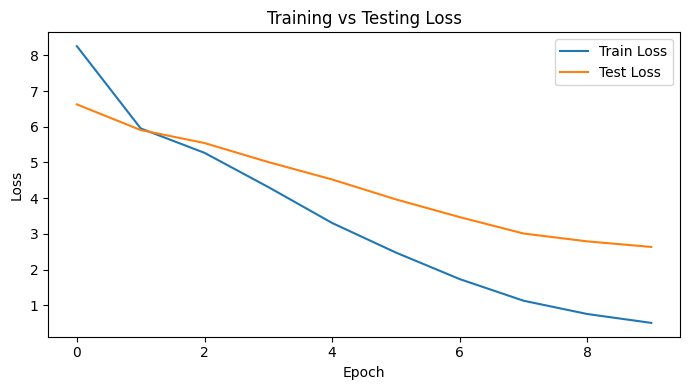

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Device check - prioritize MPS (Apple Silicon) > CUDA > CPU
if torch.backends.mps.is_available():
    device = torch.device('mps')
    print("Using MPS (Apple Silicon) device")
elif torch.cuda.is_available():
    device = torch.device('cuda')
    print("Using CUDA device")
else:
    device = torch.device('cpu')
    print("Using CPU device")

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)

# Move model to GPU (if available)
model.to(device)

# Prepare a loss function
loss_func = nn.CrossEntropyLoss()

# Create new optimizer instance
optimizer = torch.optim.AdamW(model.parameters(),
                              lr=0.0004, weight_decay=0.1)

num_epochs = 10

# Prepare lists for losses tracking
all_train_losses = []
all_test_losses = []

# Start training
for epoch in range(num_epochs):
    losses = []

    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        logits = model(inputs)
        loss = loss_func(logits.flatten(0, 1), labels.flatten())
        loss.backward()
        optimizer.step()

        losses.append(loss.item())


    test_loss = test(model, loss_func, test_loader, device)
    train_loss = sum(losses) / len(losses)

    print(f"Epoch: {epoch}, train loss: {train_loss:.4f}, test loss: {test_loss:.4f}")

    all_train_losses.append(train_loss)
    all_test_losses.append(test_loss)

epochs = list(range(len(all_train_losses)))

plt.figure(figsize=(7, 4))

# Loss plot
sns.lineplot(x=epochs, y=all_train_losses, label='Train Loss')
sns.lineplot(x=epochs, y=all_test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Testing Loss')

plt.tight_layout()
plt.show()

### Save model weights

In [13]:
torch.save(model.state_dict(), "model.pth")

loaded_model = GPTModel(GPT_CONFIG_124M)
loaded_model.load_state_dict(torch.load("model.pth", map_location=device))
loaded_model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (feed_forward): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (drop_shortcut): Dropout(p=0.1, inplac

### Generate text

Experiment with your own start contexts

In [14]:
start_context = "flowers"

token_ids = generate_text(
    model=loaded_model,
    idx=text_to_token_ids(start_context, tokenizer),
    max_new_tokens=20,
    context_size=GPT_CONFIG_124M["context_length"]
)

print("Output text: ", token_ids_to_text(token_ids, tokenizer))

Output text:  flowers! Of course I meant to do the picture for nothing--I told Mrs. Stroud so when
